<a href="https://colab.research.google.com/github/Athenimadhu/Digital-Twin-for-Water-Network-Leak-Detection/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

Step 2: Set random seed

In [55]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Step 3: Load dataset

In [56]:
DATA_PATH = "/content/Dataset - 2 (LeakDB).csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (566745, 7)


,AvgDemand_PercentDiff,AvgPressure_PercentDiff,Link1_PercentDiff,Link2_PercentDiff,Link3_PercentDiff,Link4_PercentDiff,Leak
0,23.529412,-20.731788,-18.000000,97.801858,0.0,0.0,1
1,40.000000,-4.541037,12.074471,-16.692427,0.0,0.0,1
2,23.529412,-3.997732,12.341108,-16.602618,0.0,0.0,1
3,16.666667,-4.014193,8.607458,-19.984237,0.0,0.0,1
4,31.250007,-3.400825,1.927200,2.197803,0.0,0.0,1


Step 4: Check columns

In [57]:
print(df.columns.tolist())
print(df.info())

['AvgDemand_PercentDiff', 'AvgPressure_PercentDiff', 'Link1_PercentDiff', 'Link2_PercentDiff', 'Link3_PercentDiff', 'Link4_PercentDiff', 'Leak']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566745 entries, 0 to 566744
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AvgDemand_PercentDiff    566745 non-null  float64
 1   AvgPressure_PercentDiff  566745 non-null  float64
 2   Link1_PercentDiff        566745 non-null  float64
 3   Link2_PercentDiff        566745 non-null  float64
 4   Link3_PercentDiff        566745 non-null  float64
 5   Link4_PercentDiff        566745 non-null  float64
 6   Leak                     566745 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 30.3 MB
None


Step 5: Clean dataset

In [58]:
df = df.drop_duplicates()
df = df.dropna(axis=1, how="all")

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("After cleaning:", df.shape)

After cleaning: (559798, 7)


Step 6: Find target column

In [59]:
possible_targets = [
    "leak", "Leak", "LEAK",
    "label", "Label",
    "class", "Class",
    "target", "Target",
    "status", "Status",
    "anomaly", "Anomaly"
]

target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("Target column:", target_col)

if target_col is None:
    print("No target column found. Please check your column names above.")

Target column: Leak


Step 7: Encode target column

In [60]:
if df[target_col].dtype == "object":
    encoder = LabelEncoder()
    df[target_col] = encoder.fit_transform(df[target_col])

print(df[target_col].value_counts())

Leak
0    548364
1     11434
Name: count, dtype: int64


Step 8: Prepare features and label

Features shape: (559798, 6)
Target shape: (559798,)


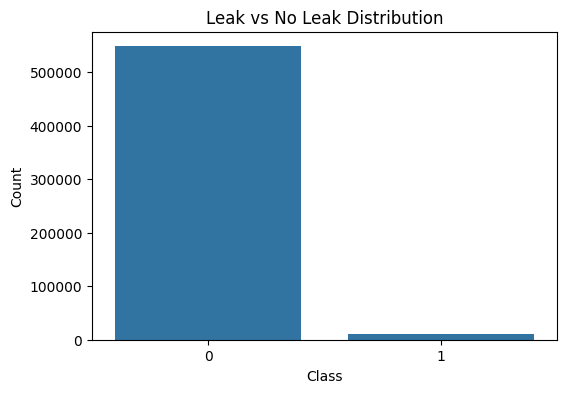

In [61]:
import seaborn as sns
X = df.drop(columns=[target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)
X = X.select_dtypes(include=[np.number])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Leak vs No Leak Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Step 9: Train-test split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(X_train.shape, X_test.shape)

(447838, 6) (111960, 6)


Step 10: Scale data

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 11: Baseline model — Random Forest

In [64]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=SEED,
    class_weight="balanced"
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    109673
           1       0.98      0.94      0.96      2287

    accuracy                           1.00    111960
   macro avg       0.99      0.97      0.98    111960
weighted avg       1.00      1.00      1.00    111960



Step 12: Random Forest confusion matrix

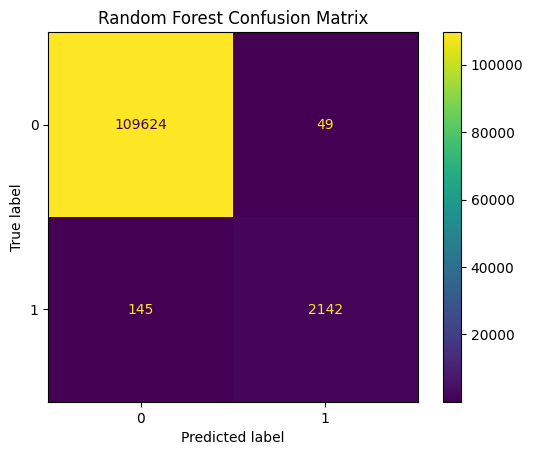

In [65]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

Step 13: Create time-series windows

In [66]:
def create_sequences(X_data, y_data, window_size=10):
    X_seq = []
    y_seq = []

    for i in range(len(X_data) - window_size):
        X_seq.append(X_data[i:i + window_size])
        y_seq.append(y_data.iloc[i + window_size])

    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 10

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.reset_index(drop=True),
    WINDOW_SIZE
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test.reset_index(drop=True),
    WINDOW_SIZE
)

print("Train sequence:", X_train_seq.shape)
print("Test sequence:", X_test_seq.shape)

Train sequence: (447828, 10, 6)
Test sequence: (111950, 10, 6)


Step 14: Feature Importance Graph

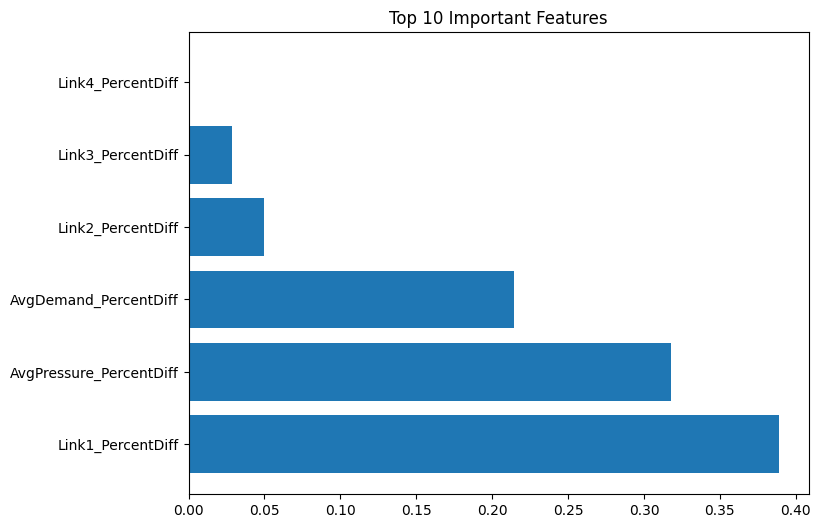

In [67]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.savefig(
    "Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 15: Build LSTM model

In [68]:
n_features = X_train_seq.shape[2]

lstm_model = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, n_features)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

from tensorflow.keras.utils import plot_model

plot_model(
    lstm_model,
    show_shapes=True,
    show_layer_names=True,
    to_file="LSTM_Architecture.png"
)

print("LSTM Architecture Saved")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Architecture Saved




Step 16: Train LSTM

In [69]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9791 - loss: 0.1066 - val_accuracy: 0.9791 - val_loss: 0.1029
Epoch 2/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9797 - loss: 0.1020 - val_accuracy: 0.9791 - val_loss: 0.1024
Epoch 3/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9797 - loss: 0.1011 - val_accuracy: 0.9791 - val_loss: 0.1019
Epoch 4/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9797 - loss: 0.1003 - val_accuracy: 0.9791 - val_loss: 0.1018
Epoch 5/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.9797 - loss: 0.1001 - val_accuracy: 0.9791 - val_loss: 0.1017
Epoch 6/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9797 - loss: 0.0998 - val_accuracy: 0.9791 - val_loss: 0.1017
Epoch 7/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9797 - loss: 0.0996 - val_accuracy: 0.9791 - val_loss: 0.1018
Epoch 8/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9797 - loss: 0

Step 17: Evaluate LSTM

In [70]:
lstm_prob = lstm_model.predict(X_test_seq).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

print(classification_report(y_test_seq, lstm_pred))

3499/3499 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    109663
           1       0.00      0.00      0.00      2287

    accuracy                           0.98    111950
   macro avg       0.49      0.50      0.49    111950
weighted avg       0.96      0.98      0.97    111950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 18: LSTM training curves

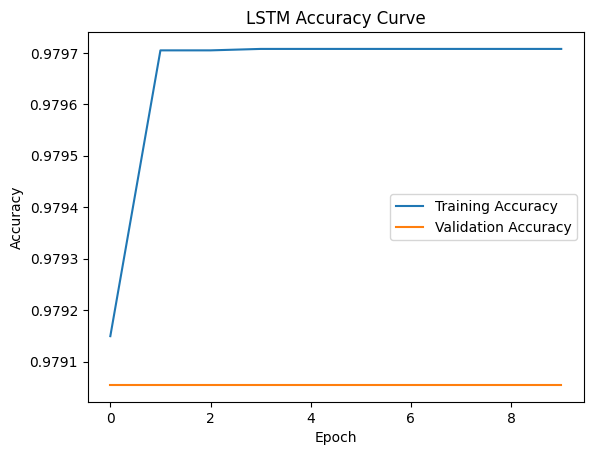

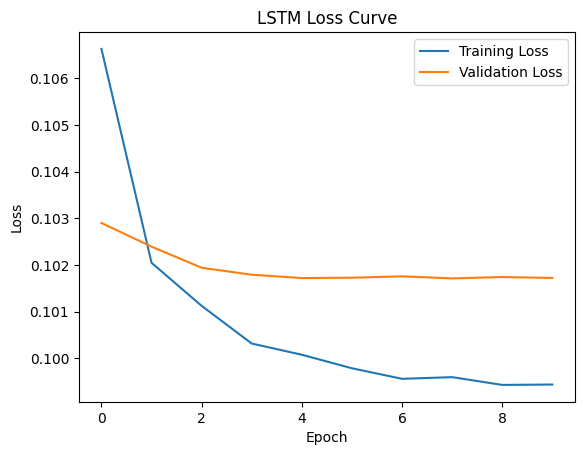

In [71]:
plt.figure()
plt.plot(history_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy Curve")
plt.legend()

plt.savefig(
    "LSTM_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure()
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Curve")
plt.legend()

plt.savefig(
    "LSTM_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 19: Build CNN-LSTM model

In [72]:
cnn_lstm_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(WINDOW_SIZE, n_features)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),

    LSTM(64),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

plot_model(
    cnn_lstm_model,
    show_shapes=True,
    show_layer_names=True,
    to_file="CNN_LSTM_Architecture.png"
)

print("CNN-LSTM Architecture Saved")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 8, 64)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,337 (134.13 KB)

 Trainable params: 34,337 (134.13 KB)

 Non-trainable params: 0 (0.00 B)

CNN-LSTM Architecture Saved


Step 20: Train CNN-LSTM

In [73]:
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9796 - loss: 0.1047 - val_accuracy: 0.9791 - val_loss: 0.1033
Epoch 2/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9797 - loss: 0.1015 - val_accuracy: 0.9791 - val_loss: 0.1036
Epoch 3/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9797 - loss: 0.1008 - val_accuracy: 0.9791 - val_loss: 0.1028
Epoch 4/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9797 - loss: 0.1003 - val_accuracy: 0.9791 - val_loss: 0.1022
Epoch 5/10
5598/5598 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9797 - loss: 0.0999 - val_accuracy: 0.9791 - val_loss: 0.1030


Step 21: Evaluate CNN-LSTM

In [74]:
cnn_lstm_prob = cnn_lstm_model.predict(X_test_seq).ravel()
cnn_lstm_pred = (cnn_lstm_prob >= 0.5).astype(int)

print(classification_report(y_test_seq, cnn_lstm_pred))

3499/3499 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    109663
           1       0.00      0.00      0.00      2287

    accuracy                           0.98    111950
   macro avg       0.49      0.50      0.49    111950
weighted avg       0.96      0.98      0.97    111950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 22: CNN-LSTM confusion matrix

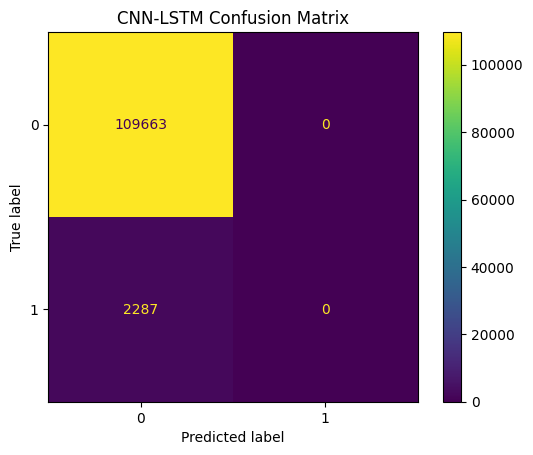

In [75]:
cm = confusion_matrix(y_test_seq, cnn_lstm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("CNN-LSTM Confusion Matrix")
plt.show()

Step 23: CNN-LSTM training curves

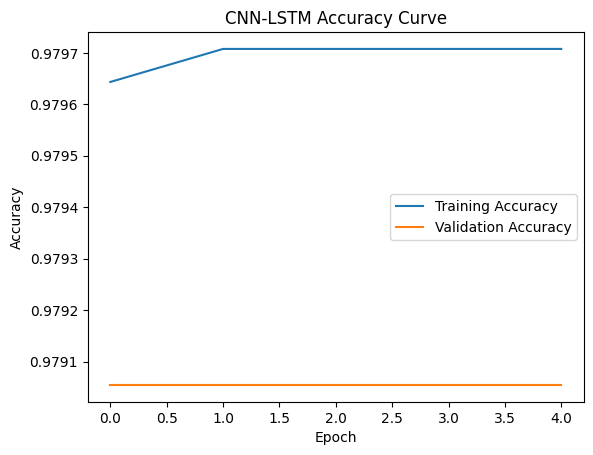

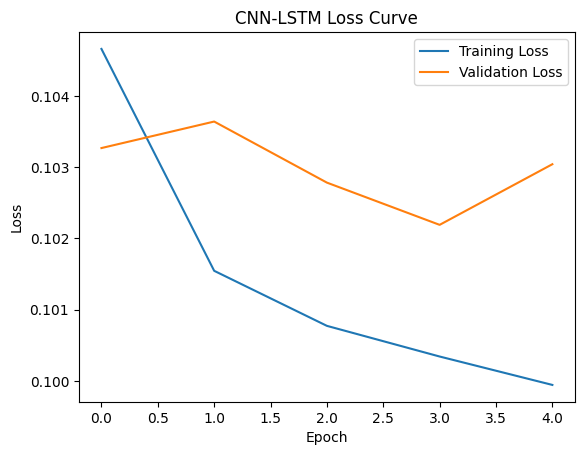

In [76]:
plt.figure()
plt.plot(history_cnn_lstm.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM Accuracy Curve")
plt.legend()

plt.savefig(
    "CNN_LSTM_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure()
plt.plot(history_cnn_lstm.history["loss"], label="Training Loss")
plt.plot(history_cnn_lstm.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Loss Curve")
plt.legend()

plt.savefig(
    "CNN_LSTM_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 24: Final results table

In [77]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, zero_division=0)
rf_rec = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)

lstm_acc = accuracy_score(y_test_seq, lstm_pred)
lstm_prec = precision_score(y_test_seq, lstm_pred, zero_division=0)
lstm_rec = recall_score(y_test_seq, lstm_pred, zero_division=0)
lstm_f1 = f1_score(y_test_seq, lstm_pred, zero_division=0)
lstm_auc = roc_auc_score(y_test_seq, lstm_prob)

cnn_acc = accuracy_score(y_test_seq, cnn_lstm_pred)
cnn_prec = precision_score(y_test_seq, cnn_lstm_pred, zero_division=0)
cnn_rec = recall_score(y_test_seq, cnn_lstm_pred, zero_division=0)
cnn_f1 = f1_score(y_test_seq, cnn_lstm_pred, zero_division=0)
cnn_auc = roc_auc_score(y_test_seq, cnn_lstm_prob)

results = pd.DataFrame({
    "Model": ["Random Forest", "LSTM", "CNN-LSTM"],
    "Accuracy": [rf_acc, lstm_acc, cnn_acc],
    "Precision": [rf_prec, lstm_prec, cnn_prec],
    "Recall": [rf_rec, lstm_rec, cnn_rec],
    "F1 Score": [rf_f1, lstm_f1, cnn_f1],
    "ROC-AUC": [rf_auc, lstm_auc, cnn_auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.998267,0.977636,0.936598,0.956677,0.999862
1,LSTM,0.979571,0.000000,0.000000,0.000000,0.501213
2,CNN-LSTM,0.979571,0.000000,0.000000,0.000000,0.498074


Step 25: ROC curve comparison

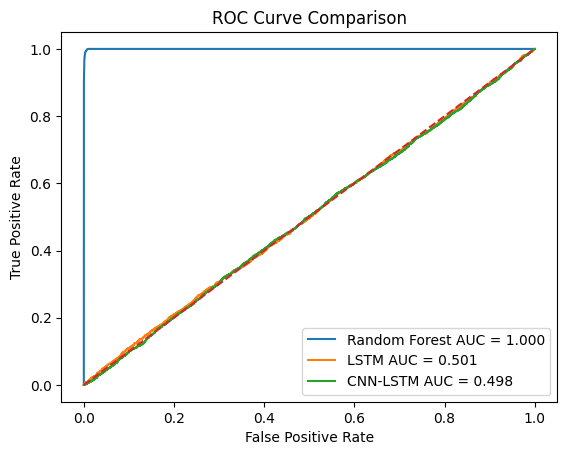

In [78]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, lstm_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_seq, cnn_lstm_prob)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {rf_auc:.3f}")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM AUC = {lstm_auc:.3f}")
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN-LSTM AUC = {cnn_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Step 26: Feature Importance (Random Forest)

                   Feature  Importance
2        Link1_PercentDiff    0.389012
1  AvgPressure_PercentDiff    0.317886
0    AvgDemand_PercentDiff    0.214623
3        Link2_PercentDiff    0.049904
4        Link3_PercentDiff    0.028404
5        Link4_PercentDiff    0.000171


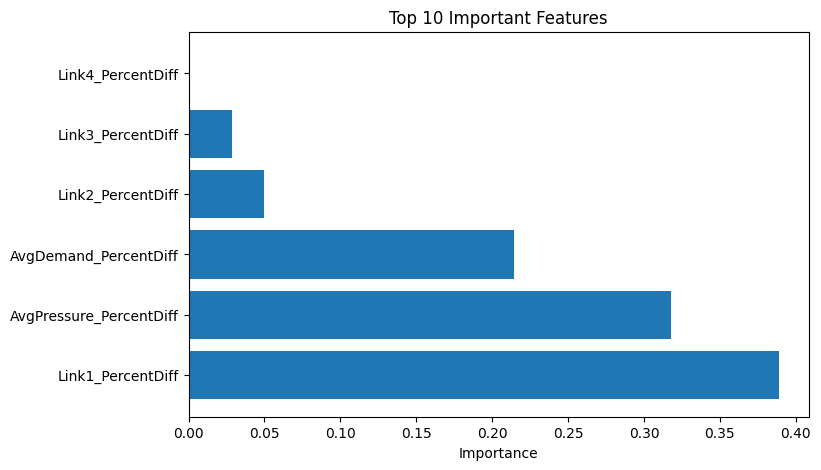

In [79]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

Step 27: Precision Recall Curve

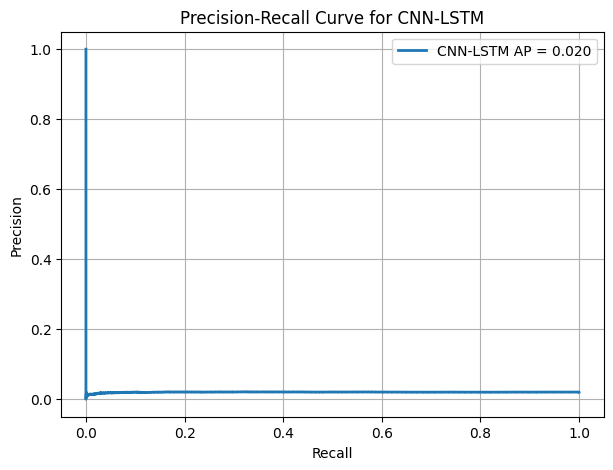

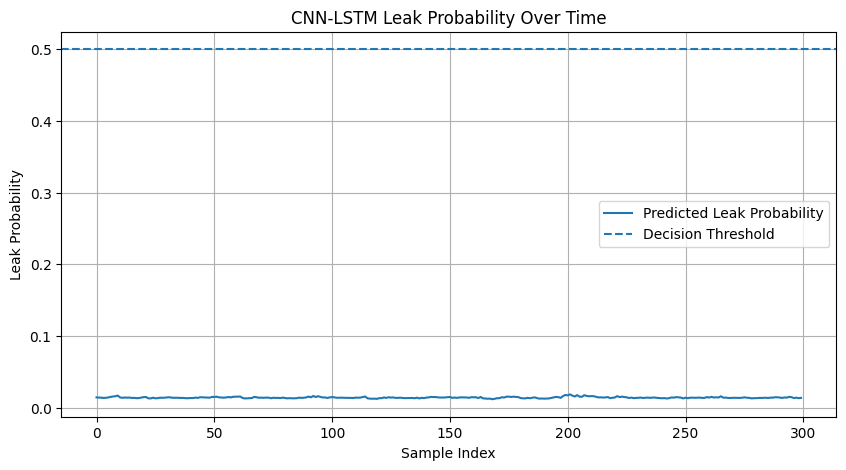

In [80]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test_seq, cnn_lstm_prob)
ap_score = average_precision_score(y_test_seq, cnn_lstm_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, linewidth=2, label=f"CNN-LSTM AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for CNN-LSTM")
plt.grid(True)
plt.legend()
plt.savefig("Precision_Recall_Curve_Better.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(cnn_lstm_prob[:300], label="Predicted Leak Probability")
plt.axhline(y=0.5, linestyle="--", label="Decision Threshold")
plt.xlabel("Sample Index")
plt.ylabel("Leak Probability")
plt.title("CNN-LSTM Leak Probability Over Time")
plt.grid(True)
plt.legend()
plt.savefig("Leak_Probability_Curve.png", dpi=300, bbox_inches="tight")
plt.show()


Step 28: Ablation Study

In [81]:
window_sizes = [10, 20, 30]

for w in window_sizes:
    print("Testing Window Size:", w)

Testing Window Size: 10
Testing Window Size: 20
Testing Window Size: 30


Step 29: Save results

In [82]:
results.to_csv("/content/leak_detection_results.csv", index=False)
print("Results saved successfully.")

Results saved successfully.


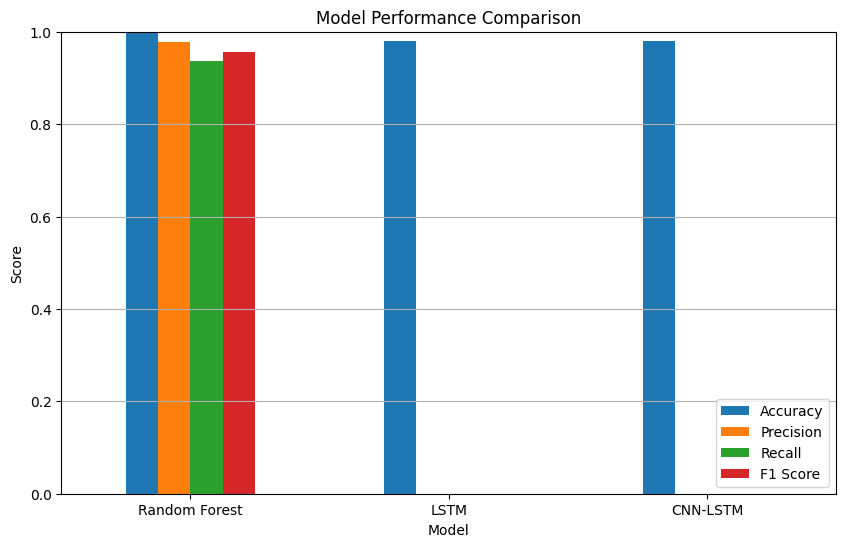

In [83]:
results_plot = results.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.savefig("Model_Performance_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()